Librerías de exploración importadas correctamente.
Error al cargar desde URL: HTTP Error 404: Not Found
Intentando cargar desde OpenML como alternativa...
Dataset cargado desde OpenML — 270 registros, 14 columnas


,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
0,0.708333,1.0,1.000000,-0.320755,-0.105023,-1.0,1.0,-0.419847,-1.0,-0.225806,0.0,1.000000,-1.0,1.0
1,0.583333,-1.0,0.333333,-0.603774,1.000000,-1.0,1.0,0.358779,-1.0,-0.483871,0.0,-1.000000,1.0,-1.0
2,0.166667,1.0,-0.333333,-0.433962,-0.383562,-1.0,-1.0,0.068702,-1.0,-0.903226,-1.0,-1.000000,1.0,1.0
3,0.458333,1.0,1.000000,-0.358491,-0.374429,-1.0,-1.0,-0.480916,1.0,-0.935484,0.0,-0.333333,1.0,-1.0
4,0.875000,-1.0,-0.333333,-0.509434,-0.347032,-1.0,1.0,-0.236641,1.0,-0.935484,-1.0,-0.333333,-1.0,-1.0


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   att_1   270 non-null    float64
 1   att_2   270 non-null    float64
 2   att_3   270 non-null    float64
 3   att_4   270 non-null    float64
 4   att_5   270 non-null    float64
 5   att_6   270 non-null    float64
 6   att_7   270 non-null    float64
 7   att_8   270 non-null    float64
 8   att_9   270 non-null    float64
 9   att_10  270 non-null    float64
 10  att_11  270 non-null    float64
 11  att_12  270 non-null    float64
 12  att_13  270 non-null    float64
 13  target  270 non-null    float64
dtypes: float64(14)
memory usage: 29.7 KB




,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,0.06,0.36,0.45,-0.30,-0.44,-0.70,0.02,0.20,-0.34,-0.66,-0.41,-0.55,-0.15,-0.11
std,0.38,0.94,0.63,0.34,0.24,0.71,1.00,0.35,0.94,0.37,0.61,0.63,0.97,1.00
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-0.21,-1.00,0.33,-0.51,-0.60,-1.00,-1.00,-0.05,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
50%,0.08,1.00,0.33,-0.32,-0.46,-1.00,1.00,0.26,-1.00,-0.74,0.00,-1.00,-1.00,-1.00
75%,0.33,1.00,1.00,-0.13,-0.30,-1.00,1.00,0.45,1.00,-0.48,0.00,-0.33,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



Valores nulos por columna:
att_1     0
att_2     0
att_3     0
att_4     0
att_5     0
att_6     0
att_7     0
att_8     0
att_9     0
att_10    0
att_11    0
att_12    0
att_13    0
target    0
dtype: int64
Registros duplicados: 0
Registros finales después de limpieza: 270


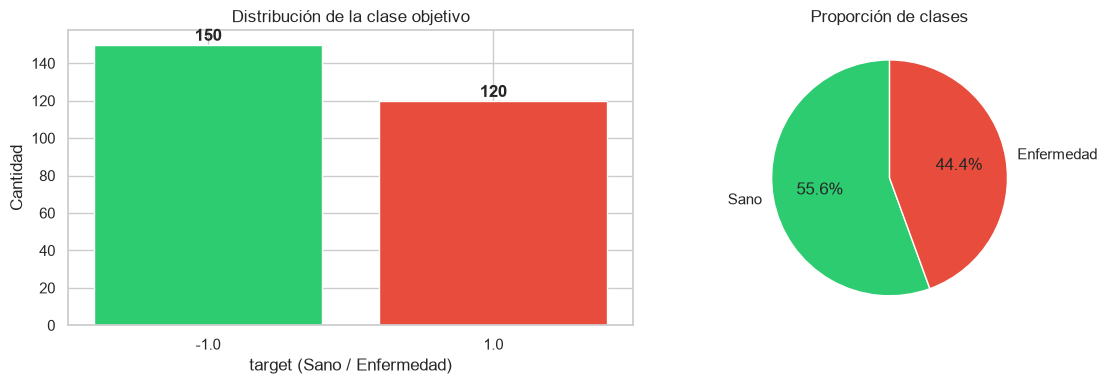

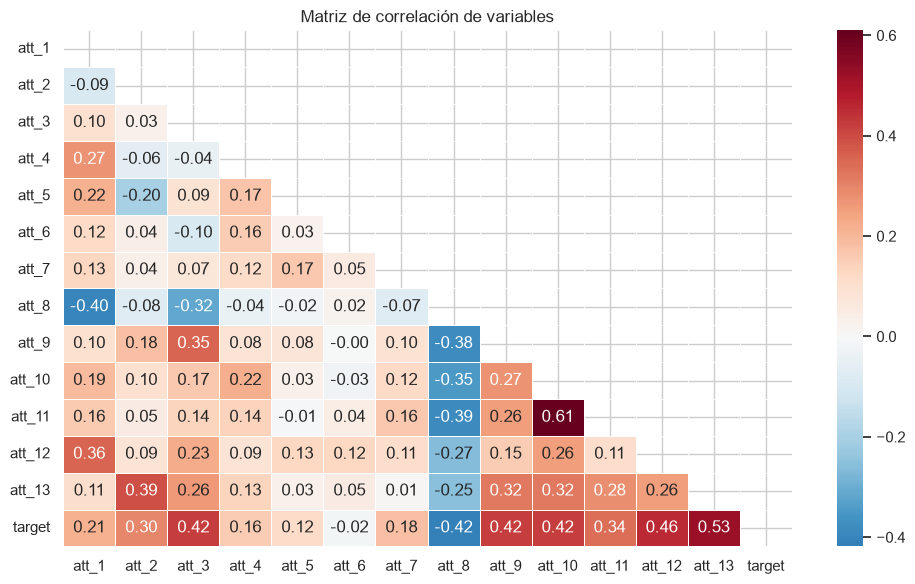

In [1]:
# ==========================================
# Célda 1: Configuración del entorno
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías de exploración importadas correctamente.')

# ==========================================
# Célda 2: Carga del Dataset
# ==========================================
URL = 'https://raw.githubusercontent.com/reddyprasade/Machine-Learning/master/Heart-Disease-UCI/heart.csv'

try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Intentando cargar desde OpenML como alternativa...')
    from sklearn.datasets import fetch_openml
    import scipy.sparse
    
    full_bunch = fetch_openml(data_id=1574, as_frame=False, return_X_y=False)
    feature_names = full_bunch.feature_names
    X_openml, y_openml = fetch_openml(data_id=1574, as_frame=False, return_X_y=True)
    
    if scipy.sparse.issparse(X_openml):
        X_openml = X_openml.toarray()
        
    df = pd.DataFrame(data=X_openml, columns=feature_names)
    df['target'] = pd.to_numeric(y_openml)
    print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')

display(df.head())

# ==========================================
# Célda 3: Información general y limpieza
# ==========================================
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
df.info()
print('\n')
display(df.describe().round(2))

print('\nValores nulos por columna:')
print(df.isnull().sum())
print(f'Registros duplicados: {df.duplicated().sum()}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros finales después de limpieza: {df.shape[0]}')

# ==========================================
# Célda 4: Distribución de la variable objetivo
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (Sano / Enfermedad)')
axes[0].set_ylabel('Cantidad')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Sano', 'Enfermedad'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

# ==========================================
# Célda 5: Matriz de Correlación
# ==========================================
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Matriz de correlación de variables')
plt.tight_layout()
plt.show()